<a href="https://colab.research.google.com/github/firatsayici/derinogrenme/blob/main/FIRATSAYICI_25221001012_Derinogrenme_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyin Tumoru Tespiti - YOLOv8 Derin Ogrenme Final Odevi
**Ogrenci:** Firat Sayici

Bu notebook, YOLOv8 kullanarak beyin tumoru tespiti yapmak icin tasarlanmistir.

## 1: Kutuphanelerin Kurulmasi ve Ice Aktarilmasi
YOLOv8'i iceren `ultralytics` kutuphanesini ve gerekli diger araclari yukler.

In [ ]:
# Gerekli paketlerin kurulması
!pip install ultralytics opencv-python matplotlib -q

import os
import zipfile
import requests
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import glob
from PIL import Image

print("Kutuephaneler basariyla yuklendi ve ice aktarildi!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Kutuephaneler basariyla yuklendi ve ice aktarildi!


## 2: Beyin Tumoru Veri Setinin Indirilmesi ve Cikartiimasi
Resmi Ultralytics veri setini indirir ve zip'ten cikarir. Veri seti yapisini otomatik olarak kesifeder.

In [ ]:
# Veri seti baglantilari ve hedef klasorler
url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip"
zip_name = "brain-tumor.zip"
extract_dir = "./brain-tumor-dataset"

# ZIP dosyasini indirme
if not os.path.exists(zip_name):
    print("Veri seti indiriliyor...")
    response = requests.get(url, stream=True)
    with open(zip_name, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print("Indirme tamamlandi.")
else:
    print("Veri seti zaten indirilmis.")

# ZIP dosyasini disari cikarma
if not os.path.exists(extract_dir):
    print("Zip dosyasi cikartilyior...")
    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Cikartma islemi tamamlandi.")
else:
    print("Veri seti zaten cikartiimis.")

# Veri seti klasor yapisini otomatik kesif
print("\nVeri seti klasor yapisi inceleniyor...")
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, "").count(os.sep)
    indent = "  " * level
    folder_name = os.path.basename(root)
    num_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png", ".txt"))])
    if num_files > 0:
        print(f"{indent}{folder_name}/ -> {num_files} dosya")
    elif level <= 2:
        print(f"{indent}{folder_name}/")

Veri seti indiriliyor...
Indirme tamamlandi.
Zip dosyasi cikartilyior...
Cikartma islemi tamamlandi.

Veri seti klasor yapisi inceleniyor...
brain-tumor-dataset/ -> 1 dosya
  labels/
    train/ -> 878 dosya
    val/ -> 223 dosya
  images/
    train/ -> 893 dosya
    val/ -> 223 dosya


## 3: Yapilandirma Dosyasinin Olusturulmasi
Veri seti yapisini otomatik kesifederek dogru klasor yollariyla YAML dosyasi olusturur.

In [ ]:
dataset_absolute_path = os.path.abspath(extract_dir)

def find_images_dir(base_path, split_keywords):
    for keyword in split_keywords:
        candidates = glob.glob(os.path.join(base_path, "**", keyword, "images"), recursive=True)
        if candidates:
            rel = os.path.relpath(candidates[0], base_path)
            return rel.replace("\\", "/")
        candidates = glob.glob(os.path.join(base_path, "**", keyword), recursive=True)
        for c in candidates:
            images = glob.glob(os.path.join(c, "*.jpg")) + glob.glob(os.path.join(c, "*.png"))
            if images:
                rel = os.path.relpath(c, base_path)
                return rel.replace("\\", "/")
    return None

train_rel = find_images_dir(dataset_absolute_path, ["train"])
val_rel   = find_images_dir(dataset_absolute_path, ["valid", "val"])

if train_rel is None or val_rel is None:
    raise FileNotFoundError(
        f"Egitim veya dogrulama klasoru bulunamadi!\n"
        f"train_rel={train_rel}, val_rel={val_rel}\n"
        f"Lutfen {extract_dir} altindaki klasor yapisini kontrol edin."
    )

print(f"Egitim klasoru   : {train_rel}")
print(f"Dogrulama klasoru: {val_rel}")

yaml_content = (
    f"path: {dataset_absolute_path}\n"
    f"train: {train_rel}\n"
    f"val:   {val_rel}\n"
    "\n"
    "names:\n"
    "  0: negatif\n"
    "  1: pozitif\n"
)

yaml_file_path = "brain-tumor.yaml"
with open(yaml_file_path, "w", encoding="utf-8") as f:
    f.write(yaml_content)

print(f"\n{yaml_file_path} basariyla olusturuldu!")
print("--- Dosya Icerigi ---")
print(yaml_content)

Egitim klasoru   : images/train
Dogrulama klasoru: images/val

brain-tumor.yaml basariyla olusturuldu!
--- Dosya Icerigi ---
path: /content/brain-tumor-dataset
train: images/train
val:   images/val

names:
  0: negatif
  1: pozitif



## 4: YOLOv8 Modelinin Egitilmesi (Transfer Ogrenme)
`yolov8n.pt` onceden egitilmis agirliklarini kullanarak 50 epoch egitim yapar. GPU varsa GPU, yoksa CPU kullanir.

In [ ]:
import torch

# Cihaz secimi: GPU varsa GPU kullan, yoksa CPU
device = 0 if torch.cuda.is_available() else "cpu"
print(f"Kullanilan cihaz: {'GPU (CUDA)' if device == 0 else 'CPU'}")
if device == 0:
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Onceden egitilmis YOLOv8 Nano modelini yukle
model = YOLO("yolov8n.pt")

print("\nModel egitimi baslatiliyor (50 Epoch)...")
results = model.train(
    data=yaml_file_path,
    epochs=50,
    imgsz=640,
    plots=True,
    device=device    # GPU varsa GPU, yoksa CPU otomatik secilir
)

print("\nEgitim tamamlandi!")

Kullanilan cihaz: GPU (CUDA)
   GPU: Tesla T4

Model egitimi baslatiliyor (50 Epoch)...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opse

## 5: Degerlendirme Metriklerinin ve Grafiklerin Gosterilmesi
YOLOv8'in otomatik urettigi Loss grafikleri, mAP@0.5, Precision, Recall ve Confusion Matrix gorsellestirilir.

Performans grafikleri okunuyor: runs/detect/train/



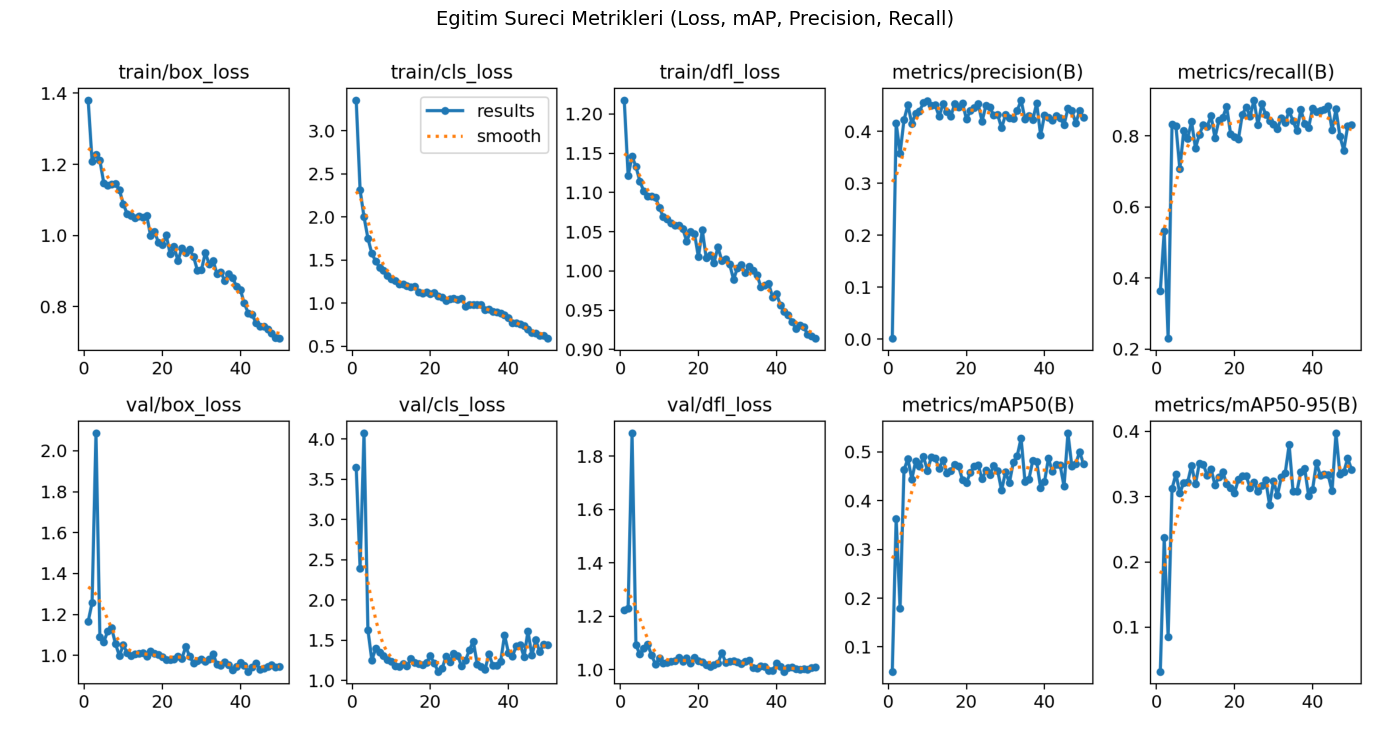

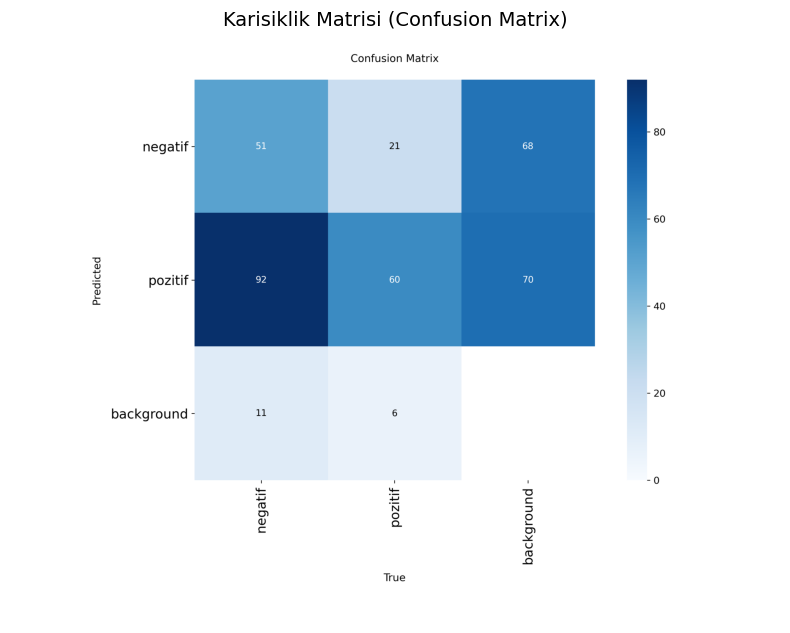

In [ ]:
# En son yapilan egitimin klasor yolunu dinamik olarak bul
folders = sorted(glob.glob("runs/detect/train*"))
if folders:
    runs_dir = folders[-1] + "/"
else:
    runs_dir = "runs/detect/train/"

print(f"Performans grafikleri okunuyor: {runs_dir}\n")

# 1. Genel Performans Metrikleri Grafigi
results_png = os.path.join(runs_dir, "results.png")
if os.path.exists(results_png):
    plt.figure(figsize=(14, 10))
    plt.imshow(Image.open(results_png))
    plt.axis("off")
    plt.title("Egitim Sureci Metrikleri (Loss, mAP, Precision, Recall)", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
else:
    print(f"UYARI: results.png bulunamadi: {results_png}")

print("\n" + "="*50 + "\n")

# 2. Karisiklik Matrisi (Confusion Matrix)
cm_png = os.path.join(runs_dir, "confusion_matrix.png")
if os.path.exists(cm_png):
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(cm_png))
    plt.axis("off")
    plt.title("Karisiklik Matrisi (Confusion Matrix)", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
else:
    print(f"UYARI: confusion_matrix.png bulunamadi: {cm_png}")

## 6: Dogrulama Seti Sonuclarinin Sayisal Analizi
Egitilen en iyi agirlik (best.pt) yuklenerek dogrulama veri setindeki sayisal basari degerleri gosterilir.

In [ ]:
# Egitilen en iyi modeli yukle
folders = sorted(glob.glob("runs/detect/train*"))
if not folders:
    raise FileNotFoundError("Egitim klasoru bulunamadi. Lutfen once egitim hucresini calistirin.")

runs_dir_local = folders[-1] + "/"
best_model_path = os.path.join(runs_dir_local, "weights/best.pt")

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"best.pt bulunamadi: {best_model_path}")

print(f"En iyi model yukleniyor: {best_model_path}")
model_best = YOLO(best_model_path)

# Dogrulama setinde modeli test et
metrics = model_best.val(data=yaml_file_path)

print("\n--- ODEV DEGERLENDIRME METRIKLERI SONUCLARI ---")
print(f"mAP@0.5 (Dogruluk Orani) : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95             : {metrics.box.map:.4f}")
print(f"Precision (Kesinlik)     : {metrics.box.mp:.4f}")
print(f"Recall (Duyarlilik)      : {metrics.box.mr:.4f}")

En iyi model yukleniyor: runs/detect/train/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 188.8±93.9 MB/s, size: 3.1 KB)
val: Scanning /content/brain-tumor-dataset/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 116.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.6it/s 3.0s
                   all        223        241      0.444      0.883      0.538      0.396
               negatif        142        154      0.593      0.812       0.64      0.471
               pozitif         81         87      0.296      0.954      0.436      0.321
Speed: 2.6ms preprocess, 4.4ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/runs/detect/val

--- ODEV DEGERLENDIRME METRIKLERI S

## 7: Modelin Yeni MR Goruntuleri Uzerinde Test Edilmesi
Dogrulama kumesinden rastgele 3 MR goruntusu secer ve tahmin kutulariyla gosterir.

3 adet MR goruntuleri uzerinde tumor tespiti yapiliyor...



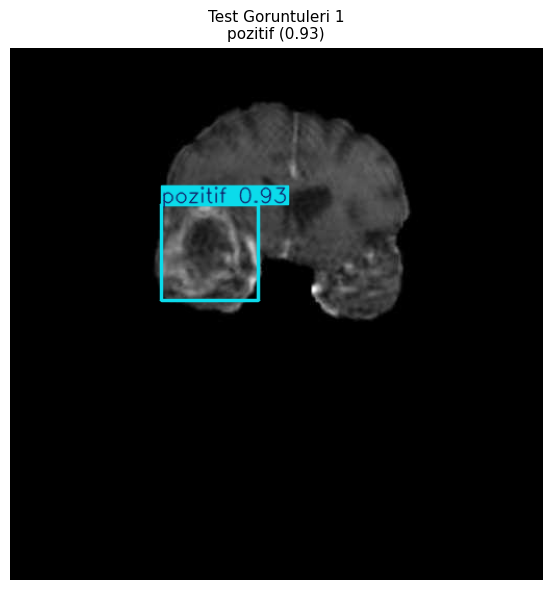

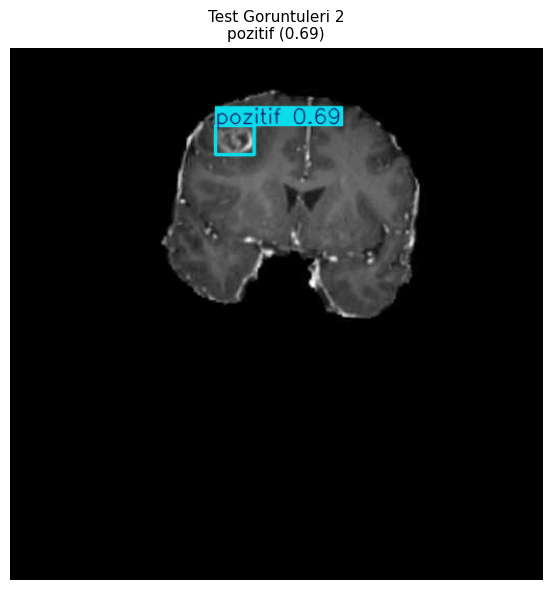

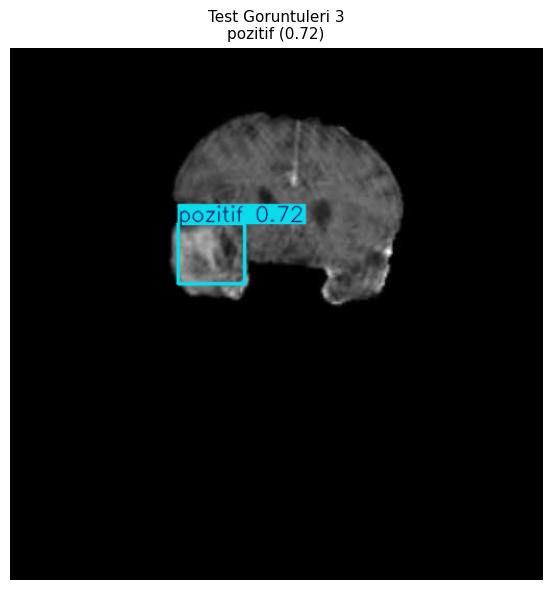


Tumor tespiti tamamlandi!


In [ ]:
# Dogrulama klasorunu dinamik olarak bul
val_images_path = os.path.join(dataset_absolute_path, val_rel)
test_images = (
    glob.glob(os.path.join(val_images_path, "*.jpg")) +
    glob.glob(os.path.join(val_images_path, "*.jpeg")) +
    glob.glob(os.path.join(val_images_path, "*.png"))
)[:3]

if not test_images:
    print(f"UYARI: Goruntu bulunamadi: {val_images_path}")
else:
    print(f"{len(test_images)} adet MR goruntuleri uzerinde tumor tespiti yapiliyor...\n")

    for idx, img_path in enumerate(test_images):
        # Model tahmini (Guven esigi: 0.25)
        results_pred = model_best.predict(source=img_path, conf=0.25, save=False, verbose=False)

        # Tespit kutularinin cizildigi resmi al ve RGB formatina donustur
        res_plotted = results_pred[0].plot()
        res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

        # Tespit sonuclari
        boxes = results_pred[0].boxes
        labels = []
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                cls_id = int(box.cls[0])
                conf_val = float(box.conf[0])
                cls_name = "pozitif" if cls_id == 1 else "negatif"
                labels.append(f"{cls_name} ({conf_val:.2f})")
        detection_str = ", ".join(labels) if labels else "Tespit yok"

        plt.figure(figsize=(6, 6))
        plt.imshow(res_rgb)
        plt.axis("off")
        plt.title(f"Test Goruntuleri {idx+1}\n{detection_str}", fontsize=11)
        plt.tight_layout()
        plt.show()

    print("\nTumor tespiti tamamlandi!")